### Gyroscope orientation - Molly

In [372]:
# import datajoint as dj
# dj.config["custom"]["database.prefix"] = "shijiegu-alt"
# from spyglass.common.custom_nwbfile import AnalysisNwbfile

In [9]:
%reload_ext autoreload
%autoreload 2

In [28]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta
from spyglass.shijiegu.load import load_position
from spyglass.shijiegu.ripple_add_replay import select_subset_helper_pd

from spyglass.common.common_position import IntervalPositionInfo
from spyglass.common.common_behav import RawPosition
from spyglass.common.common_behav import VideoFile
import os
### pick restrict to low speed moment
from spyglass.shijiegu.helpers import mergeIntervals,interpolate_to_new_time

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pynwb
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd

In [12]:
from trodestrack.models.ekf import EKFConfig, extended_kalman_filter

In [13]:
def return_gyro_trial(nwbf, t0, t1):
    # gyro
    gyrodata=nwbf.processing['analog']['analog'].time_series['analog'].data
    gyrotimestamps=nwbf.processing['analog']['analog'].time_series['analog'].timestamps
    
    timestamp_ind = np.logical_and(gyrotimestamps >= t0, gyrotimestamps <= t1)
    gyro_data_trial = gyrodata[timestamp_ind].astype("float64")
    gyro_time_trial = gyrotimestamps[timestamp_ind]

    return gyro_time_trial, gyro_data_trial

### 1. input session information

In [404]:
nwb_file_name = 'molly20220418.nwb'#'lewis20240109.nwb'
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

In [405]:
# session information
session_interval, position_interval = runSessionNames(nwb_copy_file_name)
session_name = session_interval[0]
pos_name = position_interval[0]

In [406]:
# position
key = {"nwb_file_name": nwb_copy_file_name,"interval_list_name":pos_name}
position_info = (IntervalPositionInfo() & {'nwb_file_name': nwb_copy_file_name,
                'interval_list_name': pos_name,
                "position_info_param_name": "default",
                                          }).fetch1_dataframe()

# Sensor Data
# nwb
io = pynwb.NWBHDF5IO('/stelmo/nwb/raw/'+nwb_file_name,'r')
nwbf = io.read()

[2025-12-10 21:17:22,270][WARNING]: Skipped checksum for file with hash: 377ac04c-a251-5206-84fa-9304d7869ade, and path: /stelmo/nwb/analysis/molly20220418_27AWE71ST3.nwb
[2025-12-10 21:17:22,285][WARNING]: Skipped checksum for file with hash: 377ac04c-a251-5206-84fa-9304d7869ade, and path: /stelmo/nwb/analysis/molly20220418_27AWE71ST3.nwb
[2025-12-10 21:17:22,298][WARNING]: Skipped checksum for file with hash: 377ac04c-a251-5206-84fa-9304d7869ade, and path: /stelmo/nwb/analysis/molly20220418_27AWE71ST3.nwb
[2025-12-10 21:17:22,307][WARNING]: Skipped checksum for file with hash: 377ac04c-a251-5206-84fa-9304d7869ade, and path: /stelmo/nwb/analysis/molly20220418_27AWE71ST3.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda

In [424]:
q = {"nwb_file_name": nwb_copy_file_name,
     "epoch":int(session_name[:2]),
     "proportion":str(0.1),
     "delta_t_minus":5,
     "delta_t_plus":5}

log_df = ChangeofMindTheta().fetch1_dataframe(q)

change_of_mind_trials = log_df[log_df.change_of_mind].index
print(f"Change of mind trials are: {change_of_mind_trials}")

Change of mind trials are: Index([39, 44, 48, 58, 70, 74, 80], dtype='int64')


### 2. Input trial information

In [413]:
trial1 = 43
trial2 = 45
(t0,t1) = (log_df.loc[trial1].timestamp_H, 
           log_df.loc[trial2].timestamp_O)
gyro_time_trial, gyro_data_trial = return_gyro_trial(nwbf, t0, t1)

In [415]:
position_info_upsample = interpolate_to_new_time(position_info, gyro_time_trial)
position_info_t = np.array( position_info_upsample.loc[position_info_upsample.head_speed <= 4].index )
low_speed_t = np.isin(gyro_time_trial, position_info_t)

#### 1. Use range of data to determine which channels are Gyroscope or Accelerameter

Accelerometer (±2g range)

ACCEL_SCALE = 0.000061  # g per LSB (2/32767)

accel_g = raw_value * 0.000061

accel_m_s2 = accel_g * 9.80665

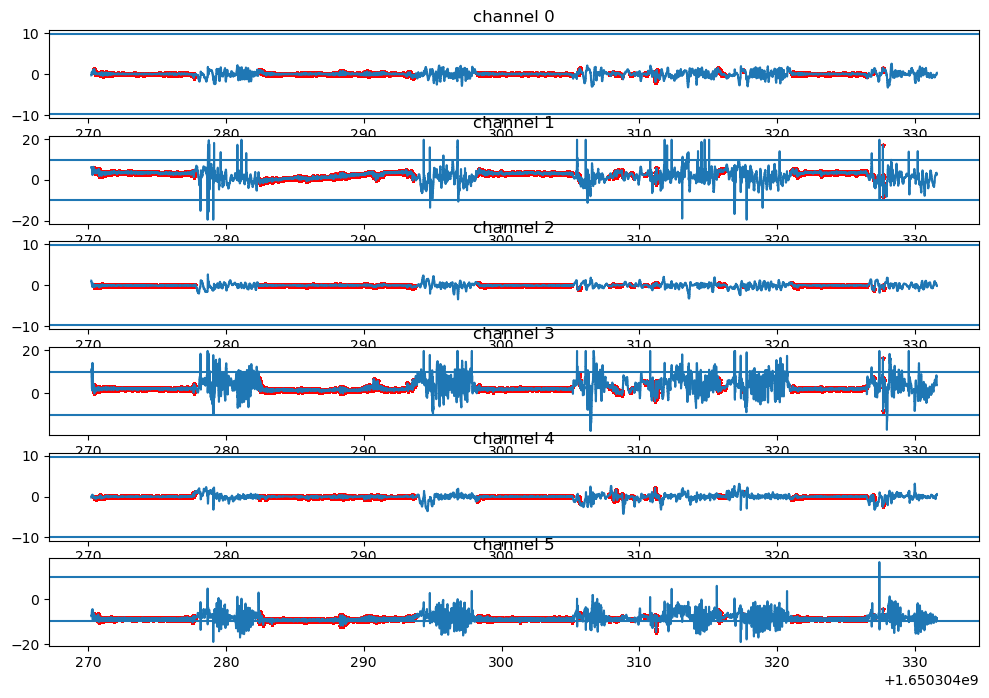

In [417]:
### First, we look for acc_z
### when the animal is still, acc_z should be -9.8
SCALE_FACTOR = 0.000061 * 9.80665 # SCALE_FACTOR for acceleration
fig, axes = plt.subplots(6,1, figsize = (12,8))

for i in range(6):
    axes[i].plot(gyro_time_trial, gyro_data_trial[:,i] * SCALE_FACTOR)
    axes[i].scatter(gyro_time_trial[low_speed_t], gyro_data_trial[low_speed_t,i] * SCALE_FACTOR,
                    marker = '*', color = 'r', label = "immobility", s = 3)
    axes[i].axhline(9.8)
    axes[i].axhline(-9.8)
    axes[i].set_title(f"channel {i}")

#### From the range, we see that Acc channels are 0,1,2 and Acc z is channel 2.

### Suppose we do scaling as if all channels are gyroscope.
Gyroscope (±2000 deg/s range)

GYRO_SCALE = 0.061  # deg/s per LSB (2000/32767)

gyro_deg_s = raw_value * 0.061

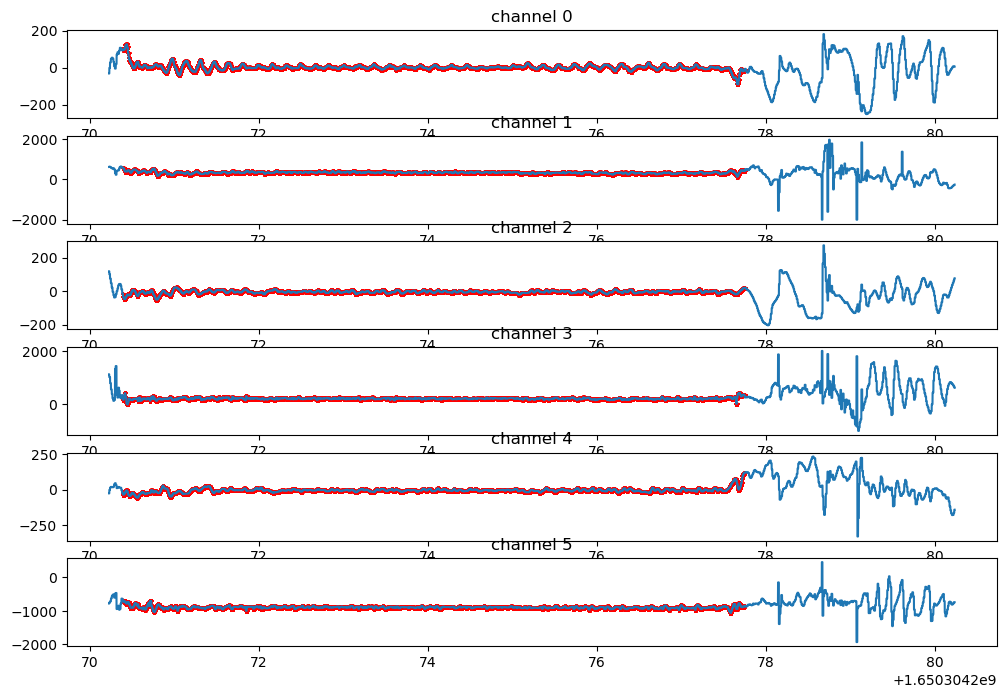

In [418]:
fig, axes = plt.subplots(6,1, figsize = (12,8))

SCALE_FACTOR = 0.061
UP_TO = 300000

for i in range(6):
    axes[i].plot(gyro_time_trial[:UP_TO], gyro_data_trial[:UP_TO,i] * SCALE_FACTOR)
    axes[i].scatter(gyro_time_trial[:UP_TO][low_speed_t[:UP_TO]], gyro_data_trial[:UP_TO][low_speed_t[:UP_TO],i] * SCALE_FACTOR,
                    marker = '*', color = 'r', label = "immobility", s = 3)
    axes[i].set_title(f"channel {i}")

#### From the range, we see that Accelerameter is channel 0, 1, 2
#### Gyroscope is channel 3, 4, 5

In [71]:
# Gyro X, Gyro Y, Gyro Z: 3 4 5
# Accel X, Accel Y, Accel Z: 0 1 2

### 2. Determine orientation:
The SpikeGadgets headstage uses a right-handed coordinate system. The physical orientation of the axes depends on how the headstage is mounted on the animal.

In [72]:
# pack data into Parquet
from trodestrack.data.analyze_imu_orientation import analyze_imu_orientation

In [349]:
analyze_imu_orientation(pos_file, imu_file, meters_per_pixel)

IMU AXIS ORIENTATION ANALYSIS

Loading data...
✓ Camera: 2,479 frames
✓ IMU: 21,745 samples

STEP 1: IDENTIFY VERTICAL AXIS (GRAVITY)

Accelerometer mean values:
  Accel X:   +0.05 ± 0.61 m/s²
  Accel Y:   -0.04 ± 0.44 m/s²
  Accel Z:   -7.75 ± 1.94 m/s² ← GRAVITY AXIS

3D magnitude: 7.75 m/s² (expected ~9.81 m/s²)

✓ Vertical axis: Z (aligned with gravity)
  Sign: negative = pointing upward in body frame

STEP 2: IDENTIFY YAW AXIS (HEADING RATE)

Method 1: Correlation of each gyro axis with heading rate from camera:
  Gyro X: r = +0.010
  Gyro Y: r = +0.151
  Gyro Z: r = -0.010

Method 2: Gyro variance (indicates which axes are most active):
  Gyro X: σ = 346.9 deg/s
  Gyro Y: σ = 49.6 deg/s
  Gyro Z: σ = 481.4 deg/s

Method 3: Physical expectation:
  → Yaw rotation should be around vertical axis: Z

✓ Yaw axis: Gyro Z (matches vertical axis)
  Correlation with heading: -0.010
  Sign: negative gyro = counterclockwise rotation

STEP 3: CORRELATE HORIZONTAL ACCEL WITH CAMERA MOTION

Cor

In [350]:
### when the animal is still, acc_z should be -9.8

### Prepare for tracking

In [87]:
from trodestrack.data.load_arthur_session import load_arthur_session

In [525]:
trial1 = 43
trial2 = 45
(t0,t1) = (log_df.loc[trial1].timestamp_H, 
           log_df.loc[trial2].timestamp_O)

io = pynwb.NWBHDF5IO('/stelmo/nwb/raw/'+nwb_file_name,'r')
nwbf = io.read()
gyro_time_trial, gyro_data_trial = return_gyro_trial(nwbf, t0, t1)

df = pd.DataFrame({"Headstage_GyroX": gyro_data_trial[:,0], #X is roll
                   "Headstage_GyroY": gyro_data_trial[:,1], #Y is pitch (milk lick associated head bobbing)
                   "Headstage_GyroZ": gyro_data_trial[:,5], #Z is yaw (rotation along xy)
                   "Headstage_AccelX": gyro_data_trial[:,2],
                   "Headstage_AccelY": gyro_data_trial[:,4],
                   "Headstage_AccelZ": gyro_data_trial[:,5]},
                   index = gyro_time_trial)


table = pa.Table.from_pandas(df)
imu_file = f'/cumulus/shijie/gyro/imu_{nwb_file_name}_{session_name}_trial{trial1}.parquet'
pq.write_table(table, imu_file)

# position
key = {"nwb_file_name": nwb_copy_file_name,"interval_list_name":pos_name}
raw_position = RawPosition.PosObject & key
spatial_series = raw_position.fetch_nwb()[0]["raw_position"]
spatial_df = raw_position.fetch1_dataframe()
spatial_subset_df = select_subset_helper_pd(spatial_df, (t0,t1))
spatial_subset_df = spatial_subset_df.dropna()
if "video_frame_ind" in spatial_subset_df.columns:
    spatial_subset_df.video_frame_ind = spatial_subset_df.video_frame_ind-np.array(
        spatial_subset_df.video_frame_ind)[0]
else:
    print("Adding video_frame_ind")
    spatial_subset_df.insert(loc=0, column='video_frame_ind', value=np.arange(len(spatial_subset_df)))

spatial_subset_df = spatial_subset_df.rename(
     columns={'xloc': 'xloc2','yloc': 'yloc2',
             'xloc2': 'xloc','yloc2': 'yloc'})

table = pa.Table.from_pandas(spatial_subset_df)

pos_file = f'/cumulus/shijie/gyro/position_{nwb_file_name}_{session_name}_trial{trial1}.parquet'
pq.write_table(table, pos_file)

meters_per_pixel = spatial_series.conversion

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.4.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cach

Adding video_frame_ind


In [527]:
analyze_imu_orientation(pos_file, imu_file, meters_per_pixel)

IMU AXIS ORIENTATION ANALYSIS

Loading data...
✓ Camera: 1,437 frames
✓ IMU: 13,189 samples

STEP 1: IDENTIFY VERTICAL AXIS (GRAVITY)

Accelerometer mean values:
  Accel X:   -0.04 ± 0.48 m/s²
  Accel Y:   -0.07 ± 0.62 m/s²
  Accel Z:   -8.36 ± 2.03 m/s² ← GRAVITY AXIS

3D magnitude: 8.36 m/s² (expected ~9.81 m/s²)

✓ Vertical axis: Z (aligned with gravity)
  Sign: negative = pointing upward in body frame

STEP 2: IDENTIFY YAW AXIS (HEADING RATE)

Method 1: Correlation of each gyro axis with heading rate from camera:
  Gyro X: r = -0.012
  Gyro Y: r = +0.062
  Gyro Z: r = +0.038

Method 2: Gyro variance (indicates which axes are most active):
  Gyro X: σ = 65.8 deg/s
  Gyro Y: σ = 275.8 deg/s
  Gyro Z: σ = 206.7 deg/s

Method 3: Physical expectation:
  → Yaw rotation should be around vertical axis: Z

✓ Yaw axis: Gyro Z (matches vertical axis)
  Correlation with heading: +0.038
  Sign: positive gyro = counterclockwise rotation

STEP 3: CORRELATE HORIZONTAL ACCEL WITH CAMERA MOTION

Cor

### Visualize packed, scaled data
- Scaling is done by the ```load_arthur_session``` function.
- We use the 3d mode to investigate all 6 channels.
- We use the 2d mode for running the Kalman filter.

In [507]:
data = load_arthur_session(pos_file, imu_file,
    verbose = True,
    imu_mode = "3d",  # Use full 6-axis IMU
    meters_per_pixel = meters_per_pixel,
)

LOADING ARTHUR SESSION

Raw data:
  Position: 1,437 frames
  IMU: 1,840,800 samples (with sample-and-hold)

Sample-and-hold removal:
  Unique samples: 6,396
  Repeat factor: 287.8×

Sampling rates:
  IMU: 100.0 Hz
  Camera: 23.4 Hz

Duration:
  IMU: 61.4 s (1.0 min)
  Camera: 61.3 s (1.0 min)
  Time overlap: 61.3 s

Unit conversions (IMU mode: 3d):
  Gyro X: [-1944.9, 1646.8] deg/s
  Gyro Y: [-1998.6, 1996.7] deg/s
  Gyro Z: [-336.5, 261.5] deg/s
  Accel X: [-3.45, 2.68] m/s²
  Accel Y: [-4.24, 3.16] m/s²
  Accel Z: [-19.07, 16.15] m/s²
  LED separation: 6.67 cm
  Arena: 1.91 × 1.88 m

Data quality check:
  3D accel magnitude: 8.43 m/s² (expected ~9.81)

✓ Data ready for trodestrack



In [508]:
# find low speed data position
t_imu = data.t_imu

key = {"nwb_file_name": nwb_copy_file_name,
       "interval_list_name": pos_name}
pos2d = (IntervalPositionInfo() & {'nwb_file_name': nwb_copy_file_name,
                'interval_list_name': pos_name,
                "position_info_param_name": "default",
                                          }).fetch1_dataframe()
pos2d.index = pos2d.index - t0
pos2d_upsample = interpolate_to_new_time(pos2d, t_imu)
pos2d_upsample_t = np.array( pos2d_upsample.loc[pos2d_upsample.head_speed <= 4].index )
low_speed_t = np.isin(t_imu, pos2d_upsample_t)

[2025-12-10 22:35:12,023][WARNING]: Skipped checksum for file with hash: 377ac04c-a251-5206-84fa-9304d7869ade, and path: /stelmo/nwb/analysis/molly20220418_27AWE71ST3.nwb
[2025-12-10 22:35:12,033][WARNING]: Skipped checksum for file with hash: 377ac04c-a251-5206-84fa-9304d7869ade, and path: /stelmo/nwb/analysis/molly20220418_27AWE71ST3.nwb
[2025-12-10 22:35:12,043][WARNING]: Skipped checksum for file with hash: 377ac04c-a251-5206-84fa-9304d7869ade, and path: /stelmo/nwb/analysis/molly20220418_27AWE71ST3.nwb
[2025-12-10 22:35:12,049][WARNING]: Skipped checksum for file with hash: 377ac04c-a251-5206-84fa-9304d7869ade, and path: /stelmo/nwb/analysis/molly20220418_27AWE71ST3.nwb


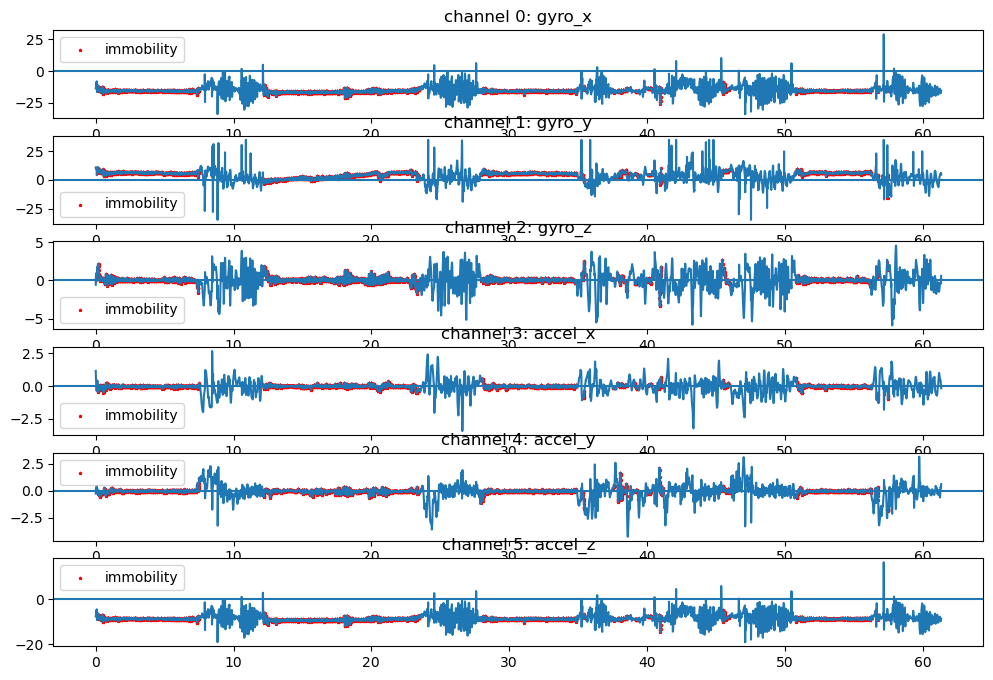

In [509]:
fig, axes = plt.subplots(6,1, figsize = (12,8))

labels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"]
for i in range(6):
    axes[i].plot(t_imu, data.U_imu[:,i])
    axes[i].scatter(t_imu[low_speed_t], data.U_imu[low_speed_t,i], marker = '*', color = 'r', label = "immobility", s = 3)
    axes[i].axhline(0)
    axes[i].set_title(f"channel {i}: {labels[i]}")
    axes[i].legend()

### Finally, do TrodesTracking

In [500]:
from trodestrack.models.ekf import EKFConfig, extended_kalman_filter

In [520]:
# Load data with 2D IMU mode
data = load_arthur_session(pos_file, imu_file,
    verbose = True,
    imu_mode = "2d",  # Use full 6-axis IMU
    meters_per_pixel = meters_per_pixel,
)

"""
default values:
process_noise_pos = 0.02
process_noise_vel = 2.0
process_noise_heading = 0.02
process_noise_gyro_bias = 2e-6
process_noise_accel_bias = 2e-4

measurement_noise_pos = 0.005**2
measurement_noise_heading = 0.05**2
"""
process_noise_heading = 0.1
process_noise_pos = 0.005 #0.02
process_noise_gyro_bias = 2e-1
measurement_noise_pos = 0.4**2
measurement_noise_heading = 0.05**2

# Configure EKF for 2D camera + 3D IMU
ekf_config = EKFConfig(
    state_mode="2d_cam_3d_imu",  # 10D state
    process_noise_pos = process_noise_pos,
    process_noise_heading = process_noise_heading,
    process_noise_vel=2.0,
    process_noise_gyro_bias=process_noise_gyro_bias,#2e-6,
    process_noise_accel_bias=2e-4,
    measurement_noise_pos = measurement_noise_pos, #0.005**2,
    measurement_noise_heading = measurement_noise_heading,
    damping_coeff=0.1,
    led_distance=data.led_distance,
)

# Run filter
result = extended_kalman_filter(
    ekf_config=ekf_config,
    t_imu=data.t_imu,
    U_imu=data.U_imu,  # [N × 6] for 3D mode
    t_cam=data.t_cam,
    Z_cam_led1=data.Z_cam_led2, # front?
    Z_cam_led2=data.Z_cam_led1, # back?
    mask_cam=data.mask_cam,
)

LOADING ARTHUR SESSION

Raw data:
  Position: 1,437 frames
  IMU: 1,840,800 samples (with sample-and-hold)

Sample-and-hold removal:
  Unique samples: 6,396
  Repeat factor: 287.8×

Sampling rates:
  IMU: 100.0 Hz
  Camera: 23.4 Hz

Duration:
  IMU: 61.4 s (1.0 min)
  Camera: 61.3 s (1.0 min)
  Time overlap: 61.3 s

Unit conversions (IMU mode: 2d):
  Gyro Z: [-336.5, 261.5] deg/s
  Accel X: [-3.45, 2.68] m/s²
  Accel Y: [-4.24, 3.16] m/s²
  LED separation: 6.67 cm
  Arena: 1.91 × 1.88 m

✓ Data ready for trodestrack



In [521]:
X_est = np.array(result.filtered_means)
P_est = np.array(result.filtered_covariances)

In [522]:
len(X_est)

1437

Text(0.5, 1.0, 'Gyro z')

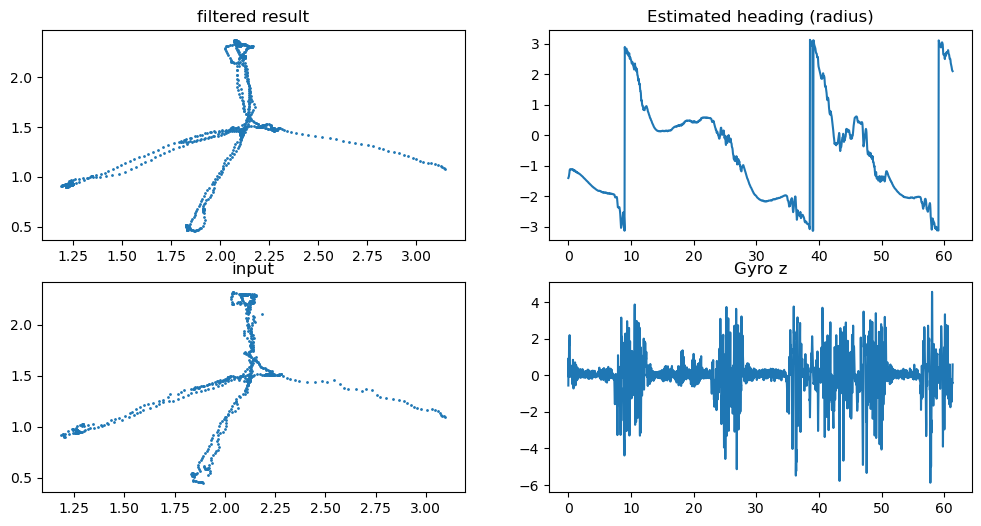

In [523]:
fig, axes = plt.subplots(2,2, figsize = (12,6))
axes[0,0].set_title("filtered result")
axes[0,0].scatter(X_est[:,0], X_est[:,1],s = 1)
axes[0,1].plot(data.t_cam, X_est[:,5])
axes[0,1].set_title("Estimated heading (radius)")
axes[1,0].set_title("input")
axes[1,0].scatter(data.Z_cam_led1[:,0], data.Z_cam_led1[:,1],s = 1)
axes[1,1].plot(data.t_imu, data.U_imu[:,0])
axes[1,1].set_title("Gyro z")

Text(0.5, 1.0, 'input')

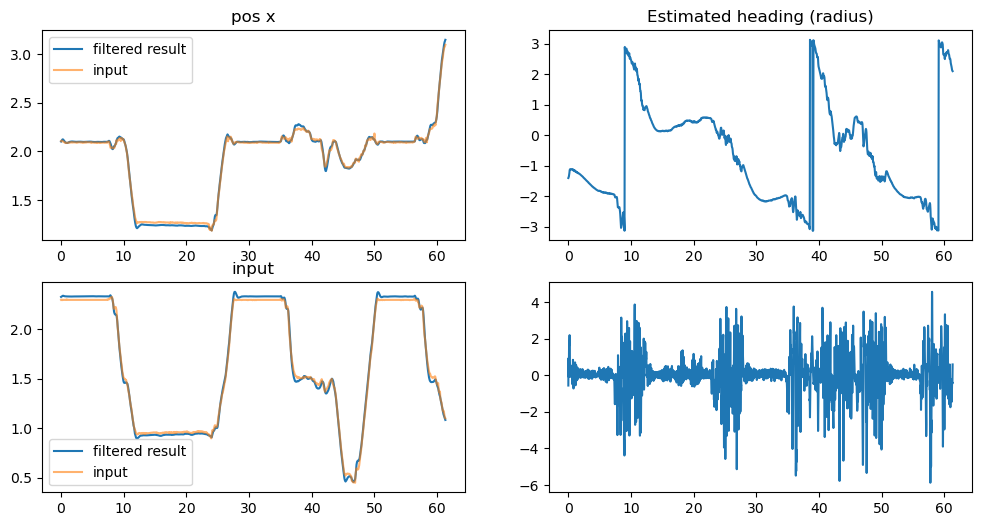

In [524]:
fig, axes = plt.subplots(2,2, figsize = (12,6))
axes[0,0].set_title("pos x")
axes[0,0].plot(data.t_cam, X_est[:,0], label = "filtered result")
axes[0,0].plot(data.t_cam, data.Z_cam_led1[:,0], label = "input", alpha = 0.6)
axes[0,0].legend()

axes[1,0].set_title("pos y")
axes[1,0].plot(data.t_cam, X_est[:,1], label = "filtered result")
axes[1,0].plot(data.t_cam, data.Z_cam_led1[:,1], label = "input", alpha = 0.6)
axes[1,0].legend()

axes[0,1].plot(data.t_cam, X_est[:,5])
axes[0,1].set_title("Estimated heading (radius)")
axes[1,1].plot(data.t_imu, data.U_imu[:,0])
axes[1,0].set_title("input")

### Make video

In [450]:
from trodestrack.data.visualize_session import create_video_overlay
from trodestrack.data.visualize_filter_overlay_fast import create_filter_overlay_video_fast

from trodestrack.data.load_arthur_session import load_video_frame

In [451]:
from spyglass.shijiegu.video import load_video_and_timestamps, make_mp4

In [452]:
cap, timestamps, meters_per_pixel = load_video_and_timestamps(nwb_copy_file_name, session_name)

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.4.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cach

In [453]:
#outputName = f'/cumulus/shijie/gyro/position_{nwb_file_name}_{session_name}_trial{trialID}'
outputName = f'position_{nwb_file_name}_{session_name}_trial{trialID}'
make_mp4(cap, timestamps, t0, t1, outputName)

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


'position_molly20220418.nwb_02_Seq2Session1_trial11_rawposition.mp4'

In [457]:
spatial_subset_df

,xloc2,yloc2,xloc,yloc
time,,,,
1.650304e+09,839,942,843,918
1.650304e+09,841,943,844,919
1.650304e+09,843,943,845,919
1.650304e+09,844,944,844,919
1.650304e+09,847,944,844,918
...,...,...,...,...
1.650304e+09,1246,445,1228,455
1.650304e+09,1252,446,1230,447
1.650304e+09,1254,434,1232,442


In [491]:
create_video_overlay(
    video_path = outputName + '_rawposition.mp4',
    data = data,
    imu_mode = "2d",
    position_df = spatial_subset_df,
    output_path = f"{nwb_file_name}_{session_name}_overlay_3DIMU.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0,
    gyro_ylim=(-200, 200),    # deg/s
    accel_ylim=(-15, 15)      # m/s²
)


CREATING VIDEO VISUALIZATION

Input video: position_molly20220418.nwb_02_Seq2Session1_trial11_rawposition.mp4
  Resolution: 1456×1088
  Frame rate: 24.0 fps
  Duration: 59.9 s

Output: molly20220418.nwb_02_Seq2Session1_overlay_3DIMU.mp4
  Start time: 0.0 s
  Duration: 61.4 s
  Output fps: 25.0

  Adjusted duration to 59.9s

Generating 1496 frames...

✓ Video saved to: molly20220418.nwb_02_Seq2Session1_overlay_3DIMU.mp4


In [ ]:
create_filter_overlay_video_fast(
    video_path = outputName + '_rawposition.mp4',
    data = data,
    filter_result = result,
    t_filter = data.t_cam,
    position_df = spatial_subset_df,
    output_path = f"filter_{nwb_file_name}_{session_name}_gyrobias{np.round(process_noise_gyro_bias,4)}_posprocessnoise{np.round(process_noise_pos,4)}_headingprocessnoise{np.round(process_noise_heading,4)}_posnoise{np.round(measurement_noise_pos,4)}_headnoise{np.round(measurement_noise_heading,4)}.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0
)

FAST FILTER OVERLAY VIDEO

Input: position_molly20220418.nwb_02_Seq2Session1_trial11_rawposition.mp4
  Resolution: 1456×1088
  Frame rate: 24.0 fps

Output: filter_molly20220418.nwb_02_Seq2Session1_gyrobias0.2_posprocessnoise0.005_headingprocessnoise0.1_posnoise0.16_headnoise0.81.mp4
  Start: 0.0s, Duration: 61.4s
  Output fps: 25.0

Generating 1534 frames...
  Progress: 0/1534 frames (0.0%)
  Progress: 30/1534 frames (2.0%)
  Progress: 60/1534 frames (3.9%)
  Progress: 90/1534 frames (5.9%)
  Progress: 120/1534 frames (7.8%)
  Progress: 150/1534 frames (9.8%)
  Progress: 180/1534 frames (11.7%)
  Progress: 210/1534 frames (13.7%)
  Progress: 240/1534 frames (15.6%)
  Progress: 270/1534 frames (17.6%)
  Progress: 300/1534 frames (19.6%)
  Progress: 330/1534 frames (21.5%)
  Progress: 360/1534 frames (23.5%)
  Progress: 390/1534 frames (25.4%)
  Progress: 420/1534 frames (27.4%)
  Progress: 450/1534 frames (29.3%)
  Progress: 480/1534 frames (31.3%)
  Progress: 510/1534 frames (33.2%)
 